# Personalization:


In [1]:
from cProfile import label

import pandas as pd
import numpy as np
import cv2
from pathlib import Path
import os
import time

In [4]:
root_folder = Path("./personalization/")
text_files = []
video_files = []

for f,folder in enumerate(root_folder.iterdir()):

    if folder.is_dir():

        print(f"\nfolder_name: {folder.name}")
        images_folder = Path(f"{root_folder}/{folder.name}/images")
        images_folder.mkdir(
                parents=True,
                exist_ok=True
            )
        # os.makedirs("images", exist_ok=True)

        for file in folder.iterdir():

            if file.suffix == ".txt" and file.name == f"{folder.name}_position.txt":
                # print("TXT gefunden:", file)
                txt_file = Path(f"{root_folder}/{folder.name}/{folder.name}_position.txt")
                print(f"Text_File: {txt_file.as_posix()}\n")
                text_files.append(txt_file.as_posix())


                

            elif file.suffix == ".mp4":
                # print("MP4 gefunden:", file)
                video_file = Path(f"{root_folder}/{folder.name}/{folder.name}_video.mp4")
                print(f"Video_File: {video_file.as_posix()}\n")
                video_files.append(video_file.as_posix())

print(f"\nText_Files: {text_files}")
print(f"\nVideo_Files: {video_files}")





# step 3:

for i in range(len(text_files)):

    labels = pd.read_csv(text_files[i], sep=",") 
    # print(labels.head())
    # print(labels.columns)

    labels.columns = labels.columns.str.strip()

    # subject_name = f"{text_files[i].split('/')[1]}"
    subject_name = Path(text_files[i]).parent.name
    print(f"\nsubject_name: {subject_name}\n")

    images_folder = Path(f"./personalization") / subject_name / "images"

    images_folder.mkdir(parents=True, exist_ok=True)


    cap = cv2.VideoCapture(video_files[i])

    rows = []
    norm_rows = []
    frame_id = 0
    saved_id = 0

    FPS = 60
    Steps = 5

    effective_fps = FPS / Steps

    # print(f"Original FPS: {FPS}")
    # print(f"Steps: {Steps}")
    # print(f"Effektive FPS: {effective_fps}")

    # Min und Max berechnen
    x_min = labels["x"].min()
    x_max = labels["x"].max()

    y_min = labels["y"].min()
    y_max = labels["y"].max()

    print(f"x_min = {x_min}, x_max = {x_max}")
    print(f"y_min = {y_min}, y_max = {y_max}")
    # x_min = 7.25, x_max = 1422.74
    # y_min = 3.89, y_max = 875.01
    
    # sys1 = "Surface"
    # sys2 = "HP"
    if subject_name == '01' or subject_name == '02' or subject_name == '03' or subject_name == '04': 
        x_max, y_max = 1430, 880
        # x_max, y_max = 1870, 1000
        
        # print(f"System: {sys1}")
        print(f"\nX_max = {x_max}, Y_max = {y_max}")

    if subject_name == '05' or subject_name == '06' or subject_name == '07' or subject_name == '08' or subject_name == '09': 
        # x_max, y_max = 1430, 880
        x_max, y_max = 1870, 1000
        
        # print(f"System: {sys2}")
        print(f"\nX_max = {x_max}, Y_max = {y_max}")
        
    # print(f"X_max = {x_max}, Y_max = {y_max}")
    # X_max = 1430, Y_max = 880

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        if frame_id % Steps == 0:

            filename = f"{saved_id:04d}.jpg"

            image_path = images_folder / filename

            cv2.imwrite(str(image_path), frame)


            rows.append({
                "frame": filename,
                "x": max(0, float(f"{(labels.loc[frame_id, "x"]):.6f}")),
                "y": max(0, float(f"{(labels.loc[frame_id, "y"]):.6f}"))
            })

            norm_rows.append({
                "frame": filename,
                "x": min(max(0, float(f"{(labels.loc[frame_id, "x"] / x_max):.6f}")), 1),
                "y": min(max(0, float(f"{(labels.loc[frame_id, "y"] / y_max):.6f}")), 1)
            })

            saved_id += 1


        frame_id += 1

    cap.release()

    pd.DataFrame(rows).to_csv(
        f"./personalization/{subject_name}/labels.csv", index=False
    )

    pd.DataFrame(norm_rows).to_csv(
        f"./personalization/{subject_name}/norm_labels.csv", index=False
        )
                


folder_name: __pycache__

folder_name: 09
Video_File: personalization/09/09_video.mp4

Text_File: personalization/09/09_position.txt


folder_name: 03
Text_File: personalization/03/03_position.txt

Video_File: personalization/03/03_video.mp4


folder_name: 06
Text_File: personalization/06/06_position.txt

Video_File: personalization/06/06_video.mp4


folder_name: 04
Video_File: personalization/04/04_video.mp4

Text_File: personalization/04/04_position.txt


folder_name: 08
Text_File: personalization/08/08_position.txt

Video_File: personalization/08/08_video.mp4


folder_name: 07
Text_File: personalization/07/07_position.txt

Video_File: personalization/07/07_video.mp4


folder_name: 05
Video_File: personalization/05/05_video.mp4

Text_File: personalization/05/05_position.txt


folder_name: 02
Video_File: personalization/02/02_video.mp4

Text_File: personalization/02/02_position.txt


folder_name: 01
Text_File: personalization/01/01_position.txt

Video_File: personalization/01/01_vide

In [74]:
# step 3:

for i in range(len(text_files)):

    labels = pd.read_csv(text_files[i], sep=",") 
    # print(labels.head())
    # print(labels.columns)

    labels.columns = labels.columns.str.strip()

    # subject_name = f"{text_files[i].split('/')[1]}"
    subject_name = Path(text_files[i]).parent.name
    print(f"\nsubject_name: {subject_name}\n")

    images_folder = Path(f"./personalization") / subject_name / "images"

    images_folder.mkdir(parents=True, exist_ok=True)


    cap = cv2.VideoCapture(video_files[i])

    rows = []
    norm_rows = []
    frame_id = 0
    saved_id = 0
    Steps = 5

    # Min und Max berechnen
    x_min = labels["x"].min()
    x_max = labels["x"].max()

    y_min = labels["y"].min()
    y_max = labels["y"].max()

    print(f"x_min = {x_min}, x_max = {x_max}")
    print(f"y_min = {y_min}, y_max = {y_max}")
    # x_min = 7.25, x_max = 1422.74
    # y_min = 3.89, y_max = 875.01

    x_max, y_max = 1870, 1000
    # print(f"X_max = {x_max}, Y_max = {y_max}")
    # X_max = 1430, Y_max = 880

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        if frame_id % Steps == 0:

            filename = f"{saved_id:04d}.jpg"

            image_path = images_folder / filename

            cv2.imwrite(str(image_path), frame)


            rows.append({
                "frame": filename,
                "x": max(0, float(f"{(labels.loc[frame_id, "x"]):.6f}")),
                "y": max(0, float(f"{(labels.loc[frame_id, "y"]):.6f}"))
            })

            norm_rows.append({
                "frame": filename,
                "x": min(max(0, float(f"{(labels.loc[frame_id, "x"] / x_max):.6f}")), 1),
                "y": min(max(0, float(f"{(labels.loc[frame_id, "y"] / y_max):.6f}")), 1)
            })

            saved_id += 1


        frame_id += 1

    cap.release()

    pd.DataFrame(rows).to_csv(
        f"./personalization/{subject_name}/labels.csv", index=False
    )

    pd.DataFrame(norm_rows).to_csv(
        f"./personalization/{subject_name}/norm_labels.csv", index=False
        )


subject_name: 09

x_min = 4.9, x_max = 1823.36
y_min = 0.1, y_max = 997.91

subject_name: 03

x_min = 2.18, x_max = 1427.71
y_min = 7.56, y_max = 875.3

subject_name: 06

x_min = 0.27, x_max = 1866.14
y_min = 1.01, y_max = 1001.9

subject_name: 04

x_min = 6.44, x_max = 1422.7
y_min = 5.38, y_max = 873.32

subject_name: 08

x_min = 7.57, x_max = 1864.95
y_min = 2.43, y_max = 997.33

subject_name: 07

x_min = 7.55, x_max = 1864.32
y_min = 1.45, y_max = 1001.87

subject_name: 05

x_min = 4.33, x_max = 1870.48
y_min = -1.1, y_max = 1000.71

subject_name: 02

x_min = -0.88, x_max = 1425.52
y_min = 7.47, y_max = 872.12

subject_name: 01

x_min = 7.25, x_max = 1422.74
y_min = 3.89, y_max = 875.01


# Random and Constant Error

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np


norm_labels_files = []

for i in range(len(text_files)+1):
    file = Path("personalization") / f"0{str(i)}" / "norm_labels.csv"

    if not file.exists():
        print(f"Fehlt: {file.resolve()}")

    else:
        norm_labels_files.append(file.as_posix())

print(f"norm_files:{norm_labels_files}")

df2 = pd.read_csv(norm_labels_files[0])

# print(df2.head())


for i in range(len(norm_labels_files)):

# -------------------------------------------------------------------
# ---------------------- Konstant_Error: ----------------------------
# -------------------------------------------------------------------

    norm_label = (norm_labels_files[i])
    # print(f"norm_file: {norm_label}")
    # norm_label = Path('./personalization/01/norm_labels.csv')
    df2 = pd.read_csv(norm_label)
    # print(df2.head())



    x_true = df2["x"].values
    y_true = df2["y"].values

    x_const = np.mean(x_true)
    y_const = np.mean(y_true)

    # x_const = 0.5
    # y_const = 0.5

    # print(f"x_const: {x_const}")
    # print(f"y_const: {y_const}")

    pred_x_const = np.full_like(x_true, x_const)
    pred_y_const = np.full_like(y_true, y_const)

    const_errors = np.sqrt(
        (x_true - pred_x_const) ** 2 +
        (y_true - pred_y_const) ** 2
    )


    mae = np.mean(const_errors)
    rmse = np.sqrt(np.mean(const_errors ** 2))
    const_error_pct = np.round(100 * rmse, 5)
    const_diagonal_error_pct = np.round(100 * rmse / np.sqrt(2), 4)

    print(f"\nKonstant Baseline: {norm_label}\n")
    # print(f"Constant_Mean_Absolute_Error: {mae}")
    # print(f"Constant_Mean_Squared_Error: {rmse}")
    # print(f"Constant_Mean_Squared_Error %: {const_error_pct} %")
    print(f"Constant_Diagonal-Error %: {const_diagonal_error_pct} %")


    # -------------------------------------------------------------------
    # ---------------------- Random-Error -------------------------------
    # -------------------------------------------------------------------

    x = df2["x"]
    y = df2["y"]
    x_max = np.max(x)
    x_min = np.min(x)
    y_max = np.max(y)
    y_min = np.min(y)

    # x_max = 1.0
    # y_max = 1.0


    pred_x_random = np.random.uniform(x_min, x_max, len(x_true))
    pred_y_random = np.random.uniform(y_min, y_max, len(y_true))

    random_errors = np.sqrt(
        (x_true - pred_x_random)**2 +
        (y_true - pred_y_random)**2
    )

    mae = np.mean(random_errors)
    rmse = np.sqrt(np.mean(random_errors ** 2))
    random_error_pct = np.round(100 * rmse, 5)
    random_diagonal_error_pct = np.round(100 * rmse / np.sqrt(2), 4)

    # print(f"\nRandom Baseline: {norm_label}\n")
    # print(f"Random_Mean_Absolute_Error: {mae}")
    # print(f"Random_Mean_Squared_Error: {rmse}")
    # print(f"Random_Mean_Squared_Error %: {random_error_pct} %")
    print(f"Random_Diagonal-Error %: {random_diagonal_error_pct} % \n\n")


Fehlt: /home/ari/PycharmProjects/Ven/Abschloss/gaze-estimation/personalization/00/norm_labels.csv
norm_files:['personalization/01/norm_labels.csv', 'personalization/02/norm_labels.csv', 'personalization/03/norm_labels.csv', 'personalization/04/norm_labels.csv', 'personalization/05/norm_labels.csv', 'personalization/06/norm_labels.csv', 'personalization/07/norm_labels.csv', 'personalization/08/norm_labels.csv', 'personalization/09/norm_labels.csv']

Konstant Baseline: personalization/01/norm_labels.csv

Constant_Diagonal-Error %: 28.77637 %
Random_Diagonal-Error %: 40.51739 % 



Konstant Baseline: personalization/02/norm_labels.csv

Constant_Diagonal-Error %: 29.30417 %
Random_Diagonal-Error %: 41.27963 % 



Konstant Baseline: personalization/03/norm_labels.csv

Constant_Diagonal-Error %: 28.75691 %
Random_Diagonal-Error %: 40.88965 % 



Konstant Baseline: personalization/04/norm_labels.csv

Constant_Diagonal-Error %: 28.50943 %
Random_Diagonal-Error %: 40.18937 % 



Konstant Baseli

# Konstant Baseline: personalization/01/norm_labels.csv

Constant_Diagonal-Error %: 28.77637 %

Random_Diagonal-Error %: 39.23223 % 



# Konstant Baseline: personalization/02/norm_labels.csv

Constant_Diagonal-Error %: 29.30417 %

Random_Diagonal-Error %: 40.91839 % 



# Konstant Baseline: personalization/03/norm_labels.csv

Constant_Diagonal-Error %: 28.75691 %

Random_Diagonal-Error %: 40.29295 % 


# Konstant Baseline: personalization/04/norm_labels.csv

Constant_Diagonal-Error %: 28.50943 %

Random_Diagonal-Error %: 40.51208 %


## Evaluation: without train

In [8]:
import numpy as np
import torch
import torch.nn as nn
from torchvision.models import resnet18

from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
from pathlib import Path
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
from tqdm import tqdm




In [9]:
class PersonalGazeDataset(Dataset):

    def __init__(
        self,
        root_dir,
        transform=None,
        dataset_size=None,
        read_all4once=True
    ):

        self.root_dir = Path(root_dir)
        self.transform = transform
        self.read_all4once = read_all4once

        self.df = pd.read_csv(
            self.root_dir / "norm_labels.csv"
        )

        self.dataset_size = (
            dataset_size
            if dataset_size is not None
            else len(self.df)
        )


        if self.read_all4once:

            # Form des transformierten Bildes bestimmen
            img = Image.new("RGB", (500, 300))
            out = transform(img)

            self.images = torch.zeros(
                [self.dataset_size] + list(out.shape)
            )

            self.targets = torch.zeros(
                self.dataset_size,
                2
            )


            for idx in tqdm(range(self.dataset_size)):

                row = self.df.iloc[idx]

                image = Image.open(
                    self.root_dir
                    / "images"
                    / row["frame"]
                ).convert("RGB")


                self.targets[idx] = torch.tensor(
                    [
                        row["x"],
                        row["y"]
                    ],
                    dtype=torch.float32
                )


                if self.transform:
                    self.images[idx] = self.transform(image)
                else:
                    self.images[idx] = image

    def __len__(self):

        return self.dataset_size


    def __getitem__(self, idx):

        if self.read_all4once:

            return (
                self.images[idx],
                self.targets[idx]
            )

        row = self.df.iloc[idx]

        image = Image.open(
            self.root_dir
            / "images"
            / row["frame"]
        ).convert("RGB")

        target = torch.tensor(
            [
                row["x"],
                row["y"]
            ],
            dtype=torch.float32
        )

        if self.transform:
            image = self.transform(image)

        return image, target

In [10]:
def diagonal_errors(model, loader, device):

    # Evaluation-Modus
    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets_all = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)

    mae = mean_absolute_error(targets_all, predictions)

    rmse = np.sqrt(mean_squared_error(targets_all, predictions))

    diagonal_error_pct = np.round(100 * (rmse / np.sqrt(2)), 5)

    print(f"MAE : {mae:.4f} \t RMSE: {rmse:.4f} ")
    # print(f"RMSE: {rmse:.4f}")
    print(f"Diagonal-Error %: {diagonal_error_pct:.4f} %")

    return mae, rmse, diagonal_error_pct

In [11]:

# Transformationen:
transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),

    transforms.RandomGrayscale(p=0.05),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1, 1.5)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [25]:
session = '09'
dataset = PersonalGazeDataset(
    root_dir=f"./personalization/09",
    transform=transform
)

print(f"\nPfade: {dataset.root_dir}\n")

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)



100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 171/171 [00:02<00:00, 59.21it/s]


Pfade: personalization/09



In [26]:
model = resnet18(weights=None)

model_name = model.__class__.__name__

print(f"\nModel: {model_name}")

# letzte Schicht ändern
model.fc = nn.Sequential(
    nn.Linear(
        model.fc.in_features,
        512
    ),
    nn.ReLU(),
    nn.Linear(
        512,
        256
    ),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(
        256,
        128
    ),
    nn.ReLU(),
    nn.Linear(
        128,
        2
    ),
    nn.Sigmoid()
)



Model: ResNet


In [27]:
saved_model_name = './models/ResNet_best_test-model_only Sigmoid_norm_subject_1000-200.path'


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Gewicht laden
checkpoint = torch.load(
    saved_model_name,
    map_location=device
)

model.load_state_dict(checkpoint)

model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [28]:
print(f"\nBaseline-Erorr: {session}")
baseline_mae, baseline_rmse, baseline_diag_pct = diagonal_errors(model, loader, device)
# diag_train_error.append(np.round(train_diag_pct, 4))

print(f"baseline_diag_error={baseline_diag_pct:.4f}%")




Baseline-Erorr: 09
MAE : 0.2341 	 RMSE: 0.2706 
Diagonal-Error %: 19.1340 %
baseline_diag_error=19.1340%


# Subject: 01
Baseline-Erorr:

MAE : 0.2494 	 

RMSE: 0.2879 

Diagonal-Error %: 20.3569 %

baseline_diag_error=20.3569%

# Subject: 02
Baseline-Erorr:

MAE : 0.2543 	 RMSE: 0.2927 

Diagonal-Error %: 20.6937 %

baseline_diag_error=20.6937%

# Subject: 03
Baseline-Erorr:

MAE : 0.2513 	 RMSE: 0.2900 

Diagonal-Error %: 20.5044 %

baseline_diag_error=20.5044%

# Subject: 04
Baseline-Erorr:

MAE : 0.2569 	 RMSE: 0.3003 

Diagonal-Error %: 21.2322 %

baseline_diag_error=21.2322%

## Evaluation: Train: 

In [29]:
# 0: Lib
import numpy as np
import torch
import torch.nn as nn
from torchvision.models import resnet18

from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
from pathlib import Path
from torchvision import transforms
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
from tqdm import tqdm
import time
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from torch.utils.data import DataLoader, Subset, random_split



In [30]:
# 1: calss PersonalGazeDataset
class PersonalGazeDataset(Dataset):

    def __init__(
        self,
        root_dir,
        transform=None,
        dataset_size=None,
        read_all4once=True
    ):

        self.root_dir = Path(root_dir)
        self.transform = transform
        self.read_all4once = read_all4once

        self.df = pd.read_csv(
            self.root_dir / "norm_labels.csv"
            # self.root_dir 
        )

        self.dataset_size = (
            dataset_size
            if dataset_size is not None
            else len(self.df)
        )


        if self.read_all4once:

            # Form des transformierten Bildes bestimmen
            img = Image.new("RGB", (500, 300))
            out = transform(img)

            self.images = torch.zeros(
                [self.dataset_size] + list(out.shape)
            )

            self.targets = torch.zeros(
                self.dataset_size,
                2
            )


            for idx in tqdm(range(self.dataset_size)):

                row = self.df.iloc[idx]

                image = Image.open(
                    self.root_dir
                    / "images"
                    / row["frame"]
                ).convert("RGB")


                self.targets[idx] = torch.tensor(
                    [
                        row["x"],
                        row["y"]
                    ],
                    dtype=torch.float32
                )


                if self.transform:
                    self.images[idx] = self.transform(image)
                else:
                    self.images[idx] = image

    def __len__(self):

        return self.dataset_size


    def __getitem__(self, idx):

        if self.read_all4once:

            return (
                self.images[idx],
                self.targets[idx]
            )

        row = self.df.iloc[idx]

        image = Image.open(
            self.root_dir
            / "images"
            / row["frame"]
        ).convert("RGB")

        target = torch.tensor(
            [
                row["x"],
                row["y"]
            ],
            dtype=torch.float32
        )

        if self.transform:
            image = self.transform(image)

        return image, target

In [194]:
class GazeVisualizer:

    def plot_ground_truth(self, targets):

        diagram_dir = "results/personal/diagrams/"
        
        if not os.path.exists(diagram_dir):
            os.makedirs(diagram_dir, 
                        exist_ok=True
                       )
        
        plt.figure(figsize=(6,6))

        plt.scatter(
            targets[:,0],
            targets[:,1],
            s=8
        )
        
        plt.title("Ground Truth")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.grid()
        plt.savefig(
            f"results/personal/diagrams/ground_truth_{split}_{active_func}_{session}_{learning_rate}.png",
            dpi=300,
            bbox_inches="tight"
        )
        
        plt.show()
        

    def plot_predictions(self, predictions):
        
        plt.figure(figsize=(6,6))

        plt.scatter(
            predictions[:,0],
            predictions[:,1],
            s=8
        )
        
        plt.title("Prediction")
        plt.grid()
        plt.savefig(
            f"results/personal/diagrams/predictions_{split}_{active_func}_{session}_{learning_rate}.png",
            dpi=300,
            bbox_inches="tight"
        )
        
        plt.show()

    
    def plot_comparison(self, predictions, targets):
        
        plt.figure(figsize=(7,7))
        
        plt.scatter(
            targets[:,0],
            targets[:,1],
            color="red",
            s=15,
            label="Ground Truth"
        )
        
        plt.scatter(
            predictions[:,0],
            predictions[:,1],
            color="blue",
            s=15,
            label="Prediction"
        )
        
        for i in range(len(targets)):
            plt.plot(
                [targets[i,0], predictions[i,0]],
                [targets[i,1], predictions[i,1]],
                color="gray",
                alpha=0.2
            )
        
        plt.legend()
        plt.grid()

        plt.savefig(
            f"results/personal/diagrams/comparison_{split}_{active_func}_{session}_{learning_rate}.png",
            dpi=300,
            bbox_inches="tight"
        )
        
        plt.show()

    
    def plot_heatmap(self, predictions):

        plt.figure(figsize=(7,6))
    
        plt.hist2d(
            predictions[:,0],
            predictions[:,1],
            bins=40,
            cmap="hot"      # oder: cmap="viridis" 
        )
        
        plt.colorbar()
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title("Prediction Heatmap")

        plt.savefig(
            f"results/personal/diagrams/Heatmap_{split}_{active_func}_{session}_{learning_rate}.png",
            dpi=300,
            bbox_inches="tight"
        )
        
        plt.show()


    
    def plot_error_heatmap(self, predictions, targets, errors):

        plt.figure(figsize=(7,6))

        plt.scatter(
            targets[:,0],
            targets[:,1],
            c=errors,
            cmap="viridis",
            s=30
        )

        plt.scatter(        
            targets[:,0],
            targets[:,1],
            c=errors,
            cmap="jet"
        
        )
        
        plt.colorbar()
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title("Prediction Heatmap")
        plt.savefig(
            f"results/personal/diagrams/Error-Heatmap_{split}_{active_func}_{session}_{learning_rate}.png",
            dpi=300,
            bbox_inches="tight"
        )
            
        plt.show()


        
    def animate_predictions(self, predictions, targets):


        plt.figure(figsize=(7,7))
        plt.ion()

        pred_x = []
        pred_y = []
        
        for i in range(len(predictions)):
        
            pred_x.append(predictions[i,0])
            pred_y.append(predictions[i,1])
        
            plt.clf()
        
            plt.scatter(
                pred_x,
                pred_y,
                s=8
            )
        
            plt.scatter(
                targets[i,0],
                targets[i,1],
                c="red",
                s=80
            )
        
            plt.pause(0.01)

        
        plt.ioff()
        plt.show()


In [31]:
# 2: func diagonal_error
def diagonal_errors(model, loader, device):

    # Evaluation-Modus
    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets_all = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)

    mae = mean_absolute_error(targets_all, predictions)

    rmse = np.sqrt(mean_squared_error(targets_all, predictions))

    diagonal_error_pct = np.round(100 * (rmse / np.sqrt(2)), 5)

    print(f"MAE : {mae:.4f} \t RMSE: {rmse:.4f} ")
    # print(f"RMSE: {rmse:.4f}")
    print(f"Diagonal-Error %: {diagonal_error_pct:.4f} %")

    return mae, rmse, diagonal_error_pct

In [32]:
def evaluate_model(model, loader, device):

    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)
    

    errors = np.sqrt(
        np.sum(
            (predictions-targets)**2,
            axis=1
        )
    )

    return targets, predictions, errors

In [73]:

def create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="random",
    seed=42,
    original_fps=60,
    frame_step=5,
    reset_interval=5,
    exclusion_time=0.5
):

    dataset_size = len(full_dataset)


    # ============================================================
    # A: Random Split
    # ============================================================

    if split_type == "random":

        generator = torch.Generator().manual_seed(seed)

        train_dataset, validat_dataset, test_dataset = random_split(
            full_dataset,
            [train_size, validat_size, test_size],
            generator=generator
        )



    # ============================================================
    # B1: Sequential Split
    # ============================================================

    elif split_type == "sequential":

        train_indices = list(
            range(0, train_size)
        )

        validat_indices = list(
            range(
                train_size,
                train_size + validat_size
            )
        )

        test_indices = list(
            range(
                train_size + validat_size,
                dataset_size
            )
        )

        train_dataset = Subset(
            full_dataset,
            train_indices
        )

        validat_dataset = Subset(
            full_dataset,
            validat_indices
        )

        test_dataset = Subset(
            full_dataset,
            test_indices
        )



    # ============================================================
    # B2: Test first, then Train + Validation
    # ============================================================

    elif split_type == "test_first_random":

        generator = torch.Generator().manual_seed(seed)

        train_valid_size = train_size + validat_size

        train_valid_dataset, test_dataset = random_split(
            full_dataset,
            [train_valid_size, test_size],
            generator=generator
        )

        train_dataset, validat_dataset = random_split(
            train_valid_dataset,
            [train_size, validat_size],
            generator=generator
        )


    # ============================================================
    # C: Video 1 = Train + Validation
    #    Video 2 = Test
    # ============================================================

    elif split_type == "different_videos":

        if test_dataset is None:

            raise ValueError(
                "Für split_type='different_videos' "
                "muss test_dataset angegeben werden."
            )


        # --------------------------------------------------------
        # Train + Validation aus Video 1
        # --------------------------------------------------------

        train_valid_size = train_size + validat_size

        if train_valid_size > len(full_dataset):

            raise ValueError(
                "Train + Validation sind größer als "
                "das Train/Validation-Video."
            )


        generator = torch.Generator().manual_seed(seed)


        train_dataset, validat_dataset = random_split(
            full_dataset,
            [train_size, validat_size],
            generator=generator
        )


        # --------------------------------------------------------
        # Test = komplettes zweites Video
        # --------------------------------------------------------

        test_dataset = test_dataset


        print("\n" + "=" * 60)
        print("DIFFERENT-VIDEO SPLIT")
        print("=" * 60)

        print(
            f"Train/Validation Video: "
            f"{len(full_dataset)} Samples"
        )

        print(
            f"Test Video: "
            f"{len(test_dataset)} Samples"
        )

        print("\nSplit:")

        print(
            f"Train:       {len(train_dataset)}"
        )

        print(
            f"Validation:  {len(validat_dataset)}"
        )

        print(
            f"Test:        {len(test_dataset)}"
        )

        print("=" * 60)


    # ============================================================
    # D: Reset-aware Random Split
    # ============================================================

    elif split_type == "reset_aware":

        # --------------------------------------------------------
        # Tatsächliche Samplingrate nach Frame-Subsampling
        # --------------------------------------------------------

        effective_fps = original_fps / frame_step


        # --------------------------------------------------------
        # Anzahl gespeicherter Samples pro Reset-Intervall
        # --------------------------------------------------------

        reset_samples = int(
            round(reset_interval * effective_fps)
        )


        # --------------------------------------------------------
        # Anzahl gespeicherter Samples, die nach jedem Reset
        # ausgeschlossen werden
        # --------------------------------------------------------

        exclusion_samples = int(
            round(exclusion_time * effective_fps)
        )


        print("\n" + "=" * 60)
        print("RESET-AWARE SPLIT")
        print("=" * 60)

        print(f"Original FPS:          {original_fps}")
        print(f"Frame Step:            {frame_step}")
        print(f"Effektive FPS:         {effective_fps}")

        print(f"\nReset alle:            {reset_interval} s")
        print(f"Reset-Samples:         {reset_samples}")

        print(f"\nAusschlusszeit:        {exclusion_time} s")
        print(f"Ausschluss-Samples:    {exclusion_samples}")


        # --------------------------------------------------------
        # Gültige und ausgeschlossene Indizes bestimmen
        # --------------------------------------------------------

        valid_indices = []
        excluded_indices = []


        for idx in range(dataset_size):

            position_in_reset = idx % reset_samples


            # Erste 0.5 Sekunden nach jedem Reset
            if position_in_reset < exclusion_samples:

                excluded_indices.append(idx)

            else:

                valid_indices.append(idx)


        print(f"\nGesamte Samples:       {dataset_size}")
        print(f"Ausgeschlossen:        {len(excluded_indices)}")
        print(f"Verwendbar:            {len(valid_indices)}")


        # --------------------------------------------------------
        # Prüfen, ob genügend Daten vorhanden sind
        # --------------------------------------------------------

        required_size = (
            train_size
            + validat_size
            + test_size
        )


        if required_size > len(valid_indices):

            raise ValueError(
                "\nNicht genügend gültige Samples!\n"
                f"Benötigt:   {required_size}\n"
                f"Verfügbar: {len(valid_indices)}"
            )


        # --------------------------------------------------------
        # Gültige Daten zufällig mischen
        # --------------------------------------------------------

        generator = torch.Generator().manual_seed(seed)

        permutation = torch.randperm(
            len(valid_indices),
            generator=generator
        ).tolist()


        shuffled_indices = [
            valid_indices[i]
            for i in permutation
        ]


        # --------------------------------------------------------
        # Train
        # --------------------------------------------------------

        train_indices = shuffled_indices[
            :train_size
        ]


        # --------------------------------------------------------
        # Validation
        # --------------------------------------------------------

        validat_indices = shuffled_indices[
            train_size:
            train_size + validat_size
        ]


        # --------------------------------------------------------
        # Test
        # --------------------------------------------------------

        test_indices = shuffled_indices[
            train_size + validat_size:
            train_size + validat_size + test_size
        ]


        # --------------------------------------------------------
        # Subsets
        # --------------------------------------------------------

        train_dataset = Subset(
            full_dataset,
            train_indices
        )

        validat_dataset = Subset(
            full_dataset,
            validat_indices
        )

        test_dataset = Subset(
            full_dataset,
            test_indices
        )


        print("\nSplit:")
        print(f"Train:                 {len(train_dataset)}")
        print(f"Validation:            {len(validat_dataset)}")
        print(f"Test:                  {len(test_dataset)}")

        print("=" * 60)


    else:

        raise ValueError(
            f"Unbekannter split_type: {split_type}"
        )


    return (
        train_dataset,
        validat_dataset,
        test_dataset
    )

In [174]:
# Hypoparameter:
batch_size = 64

epochs = 20

patience = 3                   # after 3 Epochen without Optimierung has to stop training

learning_rate = 1e-5    # 1e-4, 1e-5  

session = "04"

best_model_name = "./models/ResNet_best_optim-model_norm_subject_1000-200.path"

saved_model_name = './models/ResNet_best_test-model_only Sigmoid_norm_subject_1000-200.path'


In [175]:
# Transformationen:
transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),

    transforms.RandomGrayscale(p=0.05),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1, 1.5)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [176]:

dirs = f"personalization/{session}"

pfad = Path(dirs)/"norm_labels.csv"

if not pfad.exists():
    print(f"Fehlt: {pfad.resolve()}")

else:
    csv_pfad = pfad.as_posix()

print(f"csv_pfad: {csv_pfad}")


df3 = pd.read_csv(csv_pfad)
len_df3 = len(df3)
print(f"len(df3):{len_df3}")



train_size = int(np.round(len_df3) * 0.7) 
validat_size = int(np.round(len_df3) * 0.15) 
test_size = len_df3 - (train_size + validat_size)


sum_tvt = train_size + validat_size + test_size


print(f"\n train_size: {train_size}" 
      f"\n validat_size: {validat_size}" 
      f"\n test_size: {test_size} \n"
)

# print(f"validat_size: {validat_size}")
# print(f"test_size: {test_size}")
sum_tvt = train_size + validat_size + test_size
print(f"Summe : {sum_tvt}")

print(f"{ int(len_df3) == int(sum_tvt) }")


csv_pfad: personalization/04/norm_labels.csv
len(df3):548

 train_size: 383
 validat_size: 82
 test_size: 83 

Summe : 548
True


In [177]:
# dataset = PersonalGazeDataset(
#     root_dir=root_dirs,
#     transform=transform
# )

train_dataset = PersonalGazeDataset(
    root_dir=dirs,
    transform=transform, 
    dataset_size=train_size,
)


validat_dataset = PersonalGazeDataset(
    root_dir=dirs,
    transform=transform,
    dataset_size=validat_size,
)


test_dataset = PersonalGazeDataset(
    root_dir=dirs,
    transform=transform, 
    dataset_size=test_size,
)


print(f"\n len(train_dataset): {len(train_dataset)}")
print(f" len(validat_dataset):  {len(validat_dataset)}")
print(f" len(test_dataset): {len(test_dataset)}")




# Loader:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=8,
    persistent_workers=True
)



validat_loader = DataLoader(
    validat_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)



test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)




100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 83/83 [00:00<00:00, 96.90it/s]



 len(train_dataset): 383
 len(validat_dataset):  82
 len(test_dataset): 83


In [22]:
## Test:
# batch = next(iter(train_loader))

# images, targets = batch

# print(images.shape)
# print(targets.shape)

In [178]:
model = resnet18(weights=None)

model_name = model.__class__.__name__

print(f"\nModel: {model_name}")

# letzte Schicht ändern
model.fc = nn.Sequential(
    nn.Linear(
        model.fc.in_features,
        512
    ),
    nn.ReLU(),
    nn.Linear(
        512,
        256
    ),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(
        256,
        128
    ),
    # GaussianActivation(sigma=1.0),
    nn.ReLU(),
    nn.Linear(
        128,
        2
    ),
    nn.Sigmoid()
)

active_func = 'Sigmoid'


Model: ResNet


In [179]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Gewicht laden
# checkpoint = torch.load(
#     "./models/ResNet_optim-model_norm_subject_1000-200.path",
#     map_location=device
# )

checkpoint = torch.load(
    saved_model_name,
    map_location=device
)

model.load_state_dict(checkpoint)

model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [180]:
# 11: Loss and Optimizer ---> for regression:

# criterion = nn.MSELoss()
criterion = nn.SmoothL1Loss()


for param in model.parameters():
    param.requires_grad = False

# Unfreeze the head
for param in model.layer4.parameters():
    param.requires_grad=True
    
    model_layer4 = any(
    param.requires_grad
    for param in model.layer4.parameters()
)

    only_FC = not model_layer4
    

for param in model.fc.parameters():
    param.requires_grad=True

    model_fc = any(
    param.requires_grad
    for param in model.layer4.parameters()
)
    


optimizer = torch.optim.AdamW(
    filter(lambda p:p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=1e-5
)

# if globals().get("bas_const_err") is None:
#     bas_const_err = 27.245

# if globals().get("bas_rand_err") is None:
#     bas_rand_err = 38.961
print(f"only_FC: {only_FC} \t model_layer4: {model_layer4} \t model_FC: {model_fc}")

only_FC: False 	 model_layer4: True 	 model_FC: True


In [181]:

model_output = './models/personal'
model_dir= Path(model_output)

if not os.path.exists(model_dir):
    model_dir.mkdir(
        parents=True,
        exist_ok=True
    )

train_start = time.perf_counter()
print(f"\nSession: {session}\n")

best_error = None
diag_val_error, diag_train_error = [], []


t = 0                      # Number Epochen without Optimierung
e = 0                      # Number Epochen with Optimierung

# patience = 4               # after 4 Epochen without Optimierung has to stop training

for epoch in range(epochs):

    epoch_start = time.perf_counter()

    model.train()
    running_loss = 0

    loop = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}"
    )

    for images, targets in loop:
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        preds = model(images)

        loss = criterion(
            preds,
            targets
        )

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        loop.set_postfix(
            loss=loss.item()
        )

    # epoch_end = time.perf_counter()
    
    print(f"\n train_error:")
    train_mae, train_rmse, train_diag_pct = diagonal_errors(model, train_loader, device)
    diag_train_error.append(np.round(train_diag_pct, 4))

    print(f"\n valid_error:")
    valid_mae, valid_rmse, valid_diag_pct = diagonal_errors(model, validat_loader, device)
    diag_val_error.append(np.round(valid_diag_pct, 4))

    # --------------------------------------------------
    # Early Stopping
    # --------------------------------------------------
    
    if best_error is None or valid_diag_pct < best_error:
    
        # find an improvement
        best_error = valid_diag_pct
        t = 0
        e += 1
    
        print(
            f"Validation-Diagonal-Error: {valid_diag_pct:.4f}% | "
            f"Improvment: {e}"
        )
    
        # save the better Modell
        torch.save(
            model.state_dict(),
            f"./models/personal/{model_name}_best_model_lr({learning_rate})_"
            f"session({session}).path"
        )
    
    else:
    
        # without imporovement
        t += 1
    
        print(
            f"Patience: {t}/{patience}"
        )
    
        if t >= patience:
            print(
                f"\nEarly Stopping after {epoch + 1} Epochen."
            )
            print(
                f"Imporovments totally: {e}"
            )
            break
    
    

    epoch_end = time.perf_counter()

    print(
        f"\n[{datetime.now().strftime('%H:%M:%S')}] Epoch {epoch + 1}: {epoch_end - epoch_start:.2f} Sekunden | "
        f"Running_loss: {running_loss / len(train_loader):.3f} | "
        f"validation_diag_error={valid_diag_pct:.4f}% | "
        f"train_diag_error={train_diag_pct:.4f}% \n"
    )

    torch.save(
            model.state_dict(),
            f"./models/personal/{model_name}_last_model_lr({learning_rate})_"
            f"session({session}).path"
        )


train_end = time.perf_counter()
elapsed_running_time = train_end - train_start
print(f"min Epochs: {e}\n")
print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")


# end_time = time.perf_counter()
# elapsed_time = end_time - start_time
# print(f"\nGesamte Laufzeit: {elapsed_time:.2f} Sekunden")
# print(f"Gesamte Laufzeit: {elapsed_time/60:.2f} Minuten\n")


Session: 04



Epoch 1: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:26<00:00,  4.46s/it, loss=0.039]



 train_error:
MAE : 0.2469 	 RMSE: 0.2853 
Diagonal-Error %: 20.1734 %

 valid_error:
MAE : 0.2477 	 RMSE: 0.2847 
Diagonal-Error %: 20.1336 %
Validation-Diagonal-Error: 20.1336% | Improvment: 1

[08:05:40] Epoch 1: 48.94 Sekunden | Running_loss: 0.041 | validation_diag_error=20.1336% | train_diag_error=20.1734% 



Epoch 2: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:25<00:00,  4.26s/it, loss=0.0387]



 train_error:
MAE : 0.2451 	 RMSE: 0.2832 
Diagonal-Error %: 20.0244 %

 valid_error:
MAE : 0.2463 	 RMSE: 0.2832 
Diagonal-Error %: 20.0231 %
Validation-Diagonal-Error: 20.0231% | Improvment: 2

[08:06:26] Epoch 2: 45.91 Sekunden | Running_loss: 0.040 | validation_diag_error=20.0231% | train_diag_error=20.0244% 



...


 train_error:
MAE : 0.1720 	 RMSE: 0.2032 
Diagonal-Error %: 14.3695 %

 valid_error:
MAE : 0.1945 	 RMSE: 0.2244 
Diagonal-Error %: 15.8640 %
Validation-Diagonal-Error: 15.8640% | Improvment: 18

[08:18:28] Epoch 18: 43.58 Sekunden | Running_loss: 0.022 | validation_diag_error=15.8640% | train_diag_error=14.3695% 



Epoch 19: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:23<00:00,  3.92s/it, loss=0.0181]



 train_error:
MAE : 0.1657 	 RMSE: 0.1960 
Diagonal-Error %: 13.8560 %

 valid_error:
MAE : 0.1893 	 RMSE: 0.2186 
Diagonal-Error %: 15.4575 %
Validation-Diagonal-Error: 15.4575% | Improvment: 19

[08:19:13] Epoch 19: 45.01 Sekunden | Running_loss: 0.021 | validation_diag_error=15.4575% | train_diag_error=13.8560% 



Epoch 20: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:22<00:00,  3.75s/it, loss=0.0182]



 train_error:
MAE : 0.1592 	 RMSE: 0.1886 
Diagonal-Error %: 13.3342 %

 valid_error:
MAE : 0.1842 	 RMSE: 0.2128 
Diagonal-Error %: 15.0494 %
Validation-Diagonal-Error: 15.0494% | Improvment: 20

[08:19:58] Epoch 20: 42.19 Sekunden | Running_loss: 0.019 | validation_diag_error=15.0494% | train_diag_error=13.3342% 

min Epochs: 20


totll running-tiems (s): 906.23 Sekunden
totll running-tiems (min): 15.10 Minuten



Session: 04
split: random


 Diagonal-Train-Error: [20.1734 20.0244 19.8049 19.5512 19.295  19.0339 18.7572 18.4685 18.1608
 17.8244 17.4742 17.0893 16.6804 16.2513 15.7966 15.3319 14.8579 14.3695
 13.856  13.3342]

 Diagonal-Test-Error: [20.1336 20.0231 19.8663 19.687  19.5067 19.3215 19.1353 18.9254 18.6986
 18.4503 18.1924 17.9017 17.5956 17.263  16.9423 16.5808 16.2296 15.864
 15.4575 15.0494]


 Diagonal-Train-Error-Max: 20.1734 	 Diagonal-Train-Error-Min: 13.3342	
 Diagonal-Validation-Error-Max: 20.1336	 Diagonal-Validation-Error-Min: 15.0494	 max_needed_epochs: 20



Minimum Test Error:
Epoch:           20
Validation Error:      15.0494%
Train Error:     13.3342%
Constant Error:  28.7760%
Random Error:    39.2320%



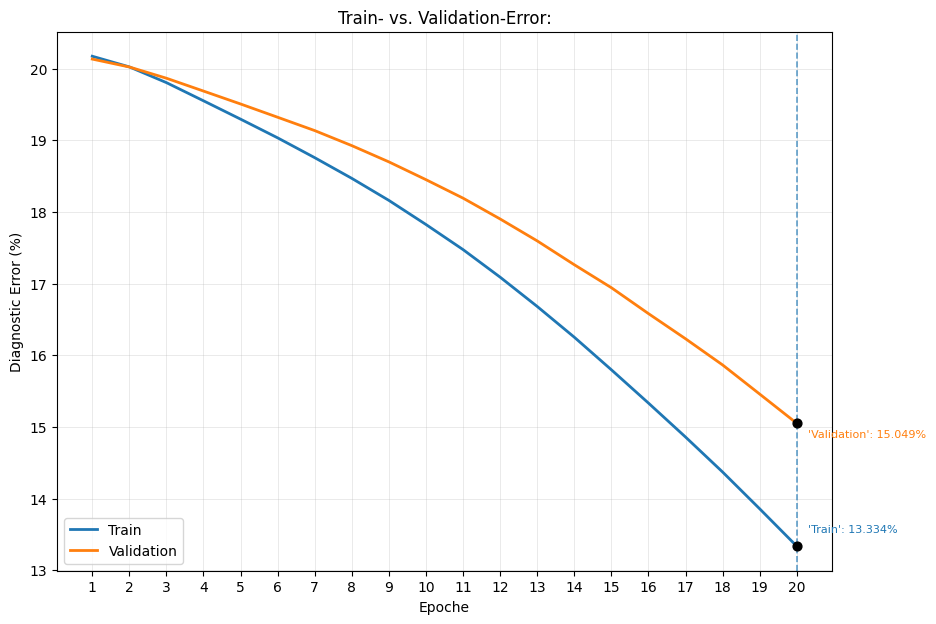

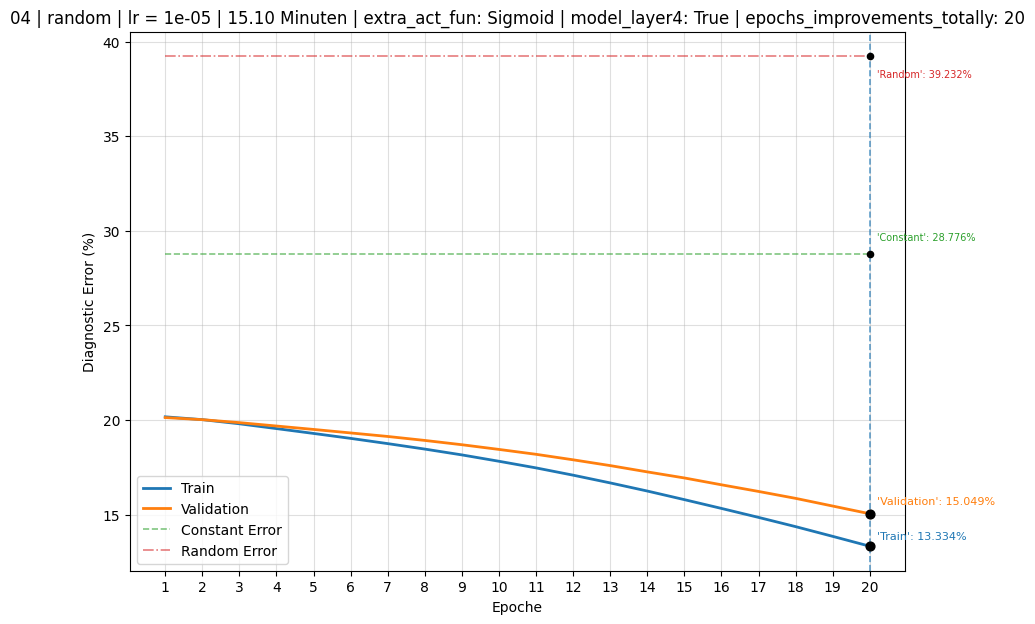

In [182]:

print(f"Session: {session}")
print(f"split: {split}")
print(f"\n\n Diagonal-Train-Error: {np.float64(diag_train_error)}\n")
print(f" Diagonal-Test-Error: {np.float64(diag_val_error)}\n\n")

print(f" Diagonal-Train-Error-Max: {np.max(diag_train_error)} \t Diagonal-Train-Error-Min: {np.min(diag_train_error)}\t")
# print(f" Diagonal-Train-Error-Ave: {np.mean(diag_train_error)}\n")

print(f" Diagonal-Validation-Error-Max: {np.max(diag_val_error)}\t Diagonal-Validation-Error-Min: {np.min(diag_val_error)}\t max_needed_epochs: {e}\n\n")
# print(f" Diagonal-Test-Error-Ave: {np.mean(diag_test_error)}\n")

# Session: 01
if globals().get("bas_const_err") is None:
    bas_const_err = 28.776

if globals().get("bas_rand_err") is None:
    bas_rand_err = 39.232

if globals().get("split") is None:
    split = "random_normal"

# Curven:

# Minimum Test Error bestimmen
min_val_error = min(diag_val_error)
min_val_epoch = diag_val_error.index(min_val_error) + 1

# Die vier Werte an dieser Epoch
train_at_min = diag_train_error[min_val_epoch - 1]
val_at_min = diag_val_error[min_val_epoch - 1]
const_at_min = bas_const_err
rand_at_min = bas_rand_err

# Die Farbe
train_color = "tab:blue"
val_color = "tab:orange"
const_color = "tab:green"
rand_color = "tab:red"
point_color = "black"

# Epochs beginnen bei 1
epochs = range(1, len(diag_val_error) + 1)
# epochs = range(0, len(diag_test_error) + 1)

plt.figure(figsize=(10, 7))

# Train Error
plt.plot(epochs, diag_train_error, label="Train", linewidth=2, color=train_color)


# Validation Error
plt.plot(epochs, diag_val_error, label="Validation", linewidth=2, color=val_color)


# Vertikale Linie durch alle vier Kurven
plt.axvline(
    x=min_val_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    # label=f"Min Test Error (Epoch {min_test_epoch})"
)

# Punkt beim Minimum des Test Errors
plt.scatter(
    min_val_epoch,
    min_val_error,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Min Test Error ({min_test_error:.2f}%)"
)

plt.scatter(
    min_val_epoch,
    train_at_min,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Train at min_Test_Error ({train_at_min_test:.2f}%)"
)

# Werte an der vertikalen Linie anzeigen
plt.annotate(
    f"'Train': {train_at_min:.3f}%",
    xy=(min_val_epoch, train_at_min),
    xytext=(8, 10),
    textcoords="offset points",
    color=train_color,
    fontsize=8
)

plt.annotate(
    f"'Validation': {val_at_min:.3f}%",
    xy=(min_val_epoch, val_at_min),
    xytext=(8, -10),
    textcoords="offset points",
    color=val_color,
    fontsize=8,
)


plt.title("Train- vs. Validation-Error:")
plt.xlabel("Epoche")
plt.ylabel("Diagnostic Error (%)")

plt.xticks(epochs)

plt.grid(True, alpha=0.3, linewidth=0.6)
plt.legend()



# ===================================================
# =============== all 4 Diagrams ====================
# ===================================================


plt.figure(figsize=(10, 7))


# Train Error
plt.plot(
    epochs,
    diag_train_error,
    label="Train",
    linewidth=2,
    color=train_color
)


# Validation Error
plt.plot(
    epochs,
    diag_val_error,
    label="Validation",
    linewidth=2,
    color=val_color
)


# Constant Baseline
plt.plot(
    epochs,
    [bas_const_err] * len(epochs),
    label="Constant Error",
    linestyle="--",
    linewidth=1.2,
    alpha=0.6,
    color=const_color
)


# Random Baseline
plt.plot(
    epochs,
    [bas_rand_err] * len(epochs),
    label="Random Error",
    linestyle="-.",
    linewidth=1.2,
    alpha=0.6,
    color=rand_color
)



print(f"\nMinimum Test Error:")
print(f"Epoch:           {min_val_epoch}")
print(f"Validation Error:      {val_at_min:.4f}%")
print(f"Train Error:     {train_at_min:.4f}%")
print(f"Constant Error:  {bas_const_err:.4f}%")
print(f"Random Error:    {bas_rand_err:.4f}%\n")


# Punkt beim Minimum des Test Errors
plt.scatter(
    min_val_epoch,
    min_val_error,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Min Test Error ({min_test_error:.2f}%)"
)

plt.scatter(
    min_val_epoch,
    train_at_min,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Train at min_Test_Error ({train_at_min_test:.2f}%)"
)

plt.scatter(
    min_val_epoch,
    const_at_min,
    s=20,
    zorder=4,
    color=point_color
)

plt.scatter(
    min_val_epoch,
    rand_at_min,
    s=20,
    zorder=4,
    color=point_color
)


# Vertikale Linie durch alle vier Kurven
plt.axvline(
    x=min_val_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    # label=f"Min Test Error (Epoch {min_test_epoch})"
)

# Werte an der vertikalen Linie anzeigen
plt.annotate(
    f"'Train': {train_at_min:.3f}%",
    xy=(min_val_epoch, train_at_min),
    xytext=(5, 5),
    textcoords="offset points",
    color=train_color,
    fontsize=8
)

plt.annotate(
    f"'Validation': {val_at_min:.3f}%",
    xy=(min_val_epoch, val_at_min),
    xytext=(5, 7),
    textcoords="offset points",
    color=val_color,
    fontsize=8
)

plt.annotate(
    f"'Constant': {const_at_min:.3f}%",
    xy=(min_val_epoch, const_at_min),
    xytext=(5, 10),
    textcoords="offset points",
    color=const_color,
    fontsize=7
)

plt.annotate(
    f"'Random': {rand_at_min:.3f}%",
    xy=(min_val_epoch, rand_at_min),
    xytext=(5, -15),
    textcoords="offset points",
    color=rand_color,
    fontsize=7
)

# Titel
plt.title(
    f"{session} | {split} | "
    f"lr = {learning_rate} | "
    f"{elapsed_running_time / 60:.2f} Minuten | "
    f"extra_act_fun: {active_func} | "
    f"model_layer4: {model_layer4} | "
    f"epochs_improvements_totally: {e}"
)
# plt.title(f"{def_dataset}((train:{def_dataset_size[0]}, test:{def_dataset_size[1]})) \n" 
#           f" lr = {learning_rate} | {elapsed_running_time/60:.2f} Minuten | extra_act_fun: {active_func} | epochs_imporovments_totally: {e+2}"
# )

plt.xlabel("Epoche")
plt.ylabel("Diagnostic Error (%)")

plt.xticks(epochs)

# plt.xticks(range(1, len(epochs) + 1, 1))
# plt.yticks(range(0, 51, 5))

plt.grid(True, alpha=0.4)
plt.legend()

# Ordner erstellen (falls er noch nicht existiert)
os.makedirs("./results/personal", exist_ok=True)

# Diagramm speichern
plt.savefig(
    f"results/personal/diag_error_{split}_{active_func}_{session}_{learning_rate}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ---------- Evaluation ----------

In [183]:
# ---------- Evaluation ----------

saved_model_name = "models/personal/ResNet_best_model_lr(1e-05)_session(01).path"

best_saved_model = f"models/personal/ResNet_best_model_lr(1e-05)_session({session}).path"

checkpoint = torch.load(
    best_saved_model,
    map_location=device
)

model.load_state_dict(checkpoint)

model.to(device)

model.eval()

print(f"Test: {session}\n")
test_mae, test_rmse, test_diag_pct = diagonal_errors(model, test_loader, device)

print(
        f"test_diag_error={test_diag_pct:.4f}% "
    )

targets, predictions, errors = evaluate_model(
    model,
    test_loader,
    device
)

Test: 04

MAE : 0.1850 	 RMSE: 0.2144 
Diagonal-Error %: 15.1623 %
test_diag_error=15.1623% 


# Test:

MAE : 0.1341 	 RMSE: 0.1672 

Diagonal-Error %: 11.8241 %

test_diag_error=11.8241%

In [184]:
import pandas as pd


results_df = pd.DataFrame({
    "gt_x": targets[:, 0],
    "gt_y": targets[:, 1],
    "pred_x": predictions[:, 0],
    "pred_y": predictions[:, 1]
})


results_df.to_csv(
    f"results/baseline_predictions{session}.csv",
    index=False
)


In [185]:
# Test:
print(results_df.head(10))

print(f"\n Anzahl Ergebnisse: {len(results_df)}\n\n")

print(results_df.shape)

       gt_x      gt_y    pred_x    pred_y
0  0.814825  0.095375  0.519903  0.424344
1  0.846979  0.117682  0.485689  0.408839
2  0.879133  0.140000  0.534680  0.422542
3  0.911287  0.162318  0.552024  0.430551
4  0.943448  0.184625  0.565968  0.446104
5  0.975601  0.206943  0.604187  0.473022
6  0.982035  0.229261  0.604077  0.453504
7  0.949874  0.251568  0.557377  0.451507
8  0.917720  0.273886  0.591370  0.467776
9  0.885566  0.296205  0.584535  0.476219

 Anzahl Ergebnisse: 83


(83, 4)


# ---------- Visualization ----------

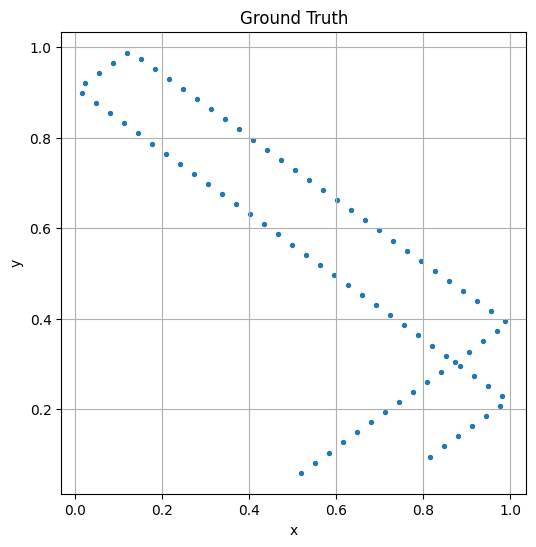

In [195]:
# ---------- Visualization ----------

vis = GazeVisualizer()

vis.plot_ground_truth(targets)


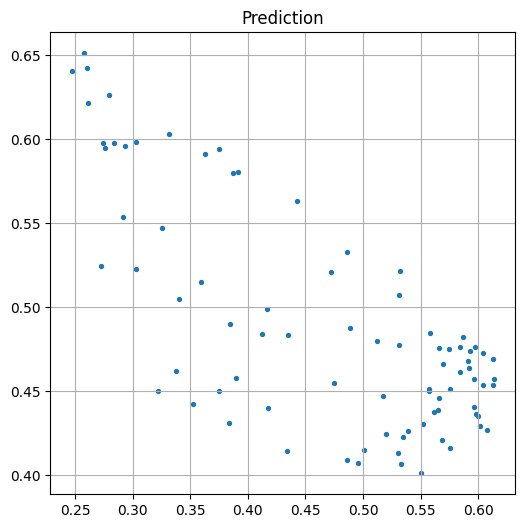

In [196]:
vis.plot_predictions(predictions)


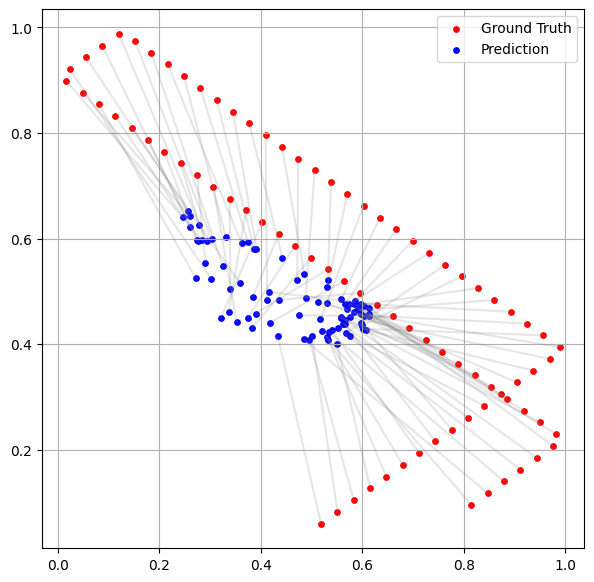

In [199]:
vis.plot_comparison(predictions, targets)


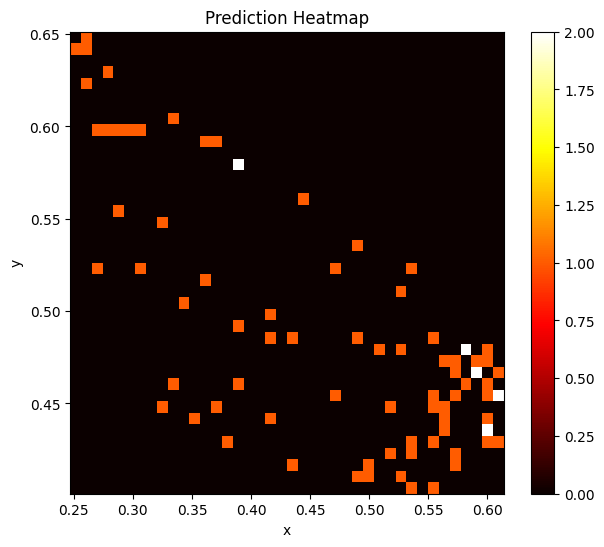

In [197]:
vis.plot_heatmap(predictions)


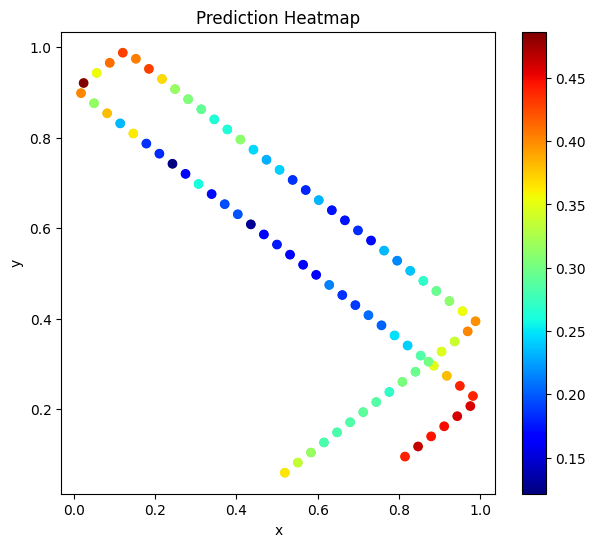

In [198]:
vis.plot_error_heatmap(
    predictions,
    targets,
    errors
)


# Split:

    a) random: 70% train, 15% validation, 15% test
    b) sequential: first 70% train, next 15% validation, last 15% test

    c) first Video for train and validation, another Video for test

    d1) train and validation: after every 5 Second start movement with a random Startpoint
    d2) test: frames start 0.5 sec after every new Starting

    e) another Video with another camera und lighing-conditions


In [164]:
dirs = f"personalization/{session}"
print(f"dirs: {dirs}")

csv_path = Path(dirs) / "norm_labels.csv"

if not csv_path.exists():
    raise FileNotFoundError(f"Fehlt: {csv_path.resolve()}")

df = pd.read_csv(csv_path)

dataset_size = len(df)

print(f"Gesamte Daten: {dataset_size}")


# ============================================================
# Vollständiges Dataset
# ============================================================

full_dataset = PersonalGazeDataset(
    root_dir=dirs,
    transform=transform,
)

print(f"len(full_dataset): {len(full_dataset)}")


dirs: personalization/08
Gesamte Daten: 156


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 156/156 [00:01<00:00, 93.02it/s]

len(full_dataset): 156


In [165]:
train_size = int(dataset_size * 0.70)
validat_size = int(dataset_size * 0.15)

test_size = dataset_size - train_size - validat_size

print(
    f"\nTrain:      {train_size} | "
    f"Validation: {validat_size} | "
    f"Test:       {test_size} | "
    f"\n\nSumme:      {train_size + validat_size + test_size}"
)



Train:      109 | Validation: 23 | Test:       24 | 

Summe:      156


# Func: Create Splits

In [130]:

def create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="random",
    seed=42,
    test_dataset=None,
    
    original_fps=60,
    frame_step=5,
    reset_interval=5,
    exclusion_time=0.5
):

    dataset_size = len(full_dataset)


    # ============================================================
    # A: Random Split
    # ============================================================

    if split_type == "random":

        generator = torch.Generator().manual_seed(seed)

        train_dataset, validat_dataset, test_dataset = random_split(
            full_dataset,
            [train_size, validat_size, test_size],
            generator=generator
        )



    # ============================================================
    # B1: Sequential Split
    # ============================================================

    elif split_type == "sequential":

        train_indices = list(
            range(0, train_size)
        )

        validat_indices = list(
            range(
                train_size,
                train_size + validat_size
            )
        )

        test_indices = list(
            range(
                train_size + validat_size,
                dataset_size
            )
        )

        train_dataset = Subset(
            full_dataset,
            train_indices
        )

        validat_dataset = Subset(
            full_dataset,
            validat_indices
        )

        test_dataset = Subset(
            full_dataset,
            test_indices
        )



    # ============================================================
    # B2: Test first, then Train + Validation
    # ============================================================

    elif split_type == "test_first_random":

        generator = torch.Generator().manual_seed(seed)

        train_valid_size = train_size + validat_size

        train_valid_dataset, test_dataset = random_split(
            full_dataset,
            [train_valid_size, test_size],
            generator=generator
        )

        train_dataset, validat_dataset = random_split(
            train_valid_dataset,
            [train_size, validat_size],
            generator=generator
        )


    # ============================================================
    # C: Video 1 = Train + Validation
    #    Video 2 = Test
    # ============================================================

    elif split_type == "different_videos":

        if test_dataset is None:

            raise ValueError(
                "Für split_type='different_videos' "
                "muss test_dataset angegeben werden."
            )


        # --------------------------------------------------------
        # Train + Validation aus Video 1
        # --------------------------------------------------------

        train_valid_size = train_size + validat_size

        if train_valid_size > len(full_dataset):

            raise ValueError(
                "Train + Validation sind größer als "
                "das Train/Validation-Video."
            )


        generator = torch.Generator().manual_seed(seed)


        train_dataset, validat_dataset = random_split(
            full_dataset,
            [train_size, validat_size],
            generator=generator
        )


        # --------------------------------------------------------
        # Test = komplettes zweites Video
        # --------------------------------------------------------

        test_dataset = test_dataset


        print("\n" + "=" * 60)
        print("DIFFERENT-VIDEO SPLIT")
        print("=" * 60)

        print(
            f"Train/Validation Video: "
            f"{len(full_dataset)} Samples"
        )

        print(
            f"Test Video: "
            f"{len(test_dataset)} Samples"
        )

        print("\nSplit:")

        print(
            f"Train:       {len(train_dataset)}"
        )

        print(
            f"Validation:  {len(validat_dataset)}"
        )

        print(
            f"Test:        {len(test_dataset)}"
        )

        print("=" * 60)


    # ============================================================
    # D: Reset-aware Random Split
    # ============================================================

    elif split_type == "reset_aware":

        # --------------------------------------------------------
        # Tatsächliche Samplingrate nach Frame-Subsampling
        # --------------------------------------------------------

        effective_fps = original_fps / frame_step


        # --------------------------------------------------------
        # Anzahl gespeicherter Samples pro Reset-Intervall
        # --------------------------------------------------------

        reset_samples = int(
            round(reset_interval * effective_fps)
        )


        # --------------------------------------------------------
        # Anzahl gespeicherter Samples, die nach jedem Reset
        # ausgeschlossen werden
        # --------------------------------------------------------

        exclusion_samples = int(
            round(exclusion_time * effective_fps)
        )


        print("\n" + "=" * 60)
        print("RESET-AWARE SPLIT")
        print("=" * 60)

        print(f"Original FPS:          {original_fps}")
        print(f"Frame Step:            {frame_step}")
        print(f"Effektive FPS:         {effective_fps}")

        print(f"\nReset alle:            {reset_interval} s")
        print(f"Reset-Samples:         {reset_samples}")

        print(f"\nAusschlusszeit:        {exclusion_time} s")
        print(f"Ausschluss-Samples:    {exclusion_samples}")


        # --------------------------------------------------------
        # Gültige und ausgeschlossene Indizes bestimmen
        # --------------------------------------------------------

        valid_indices = []
        excluded_indices = []


        for idx in range(dataset_size):

            position_in_reset = idx % reset_samples


            # Erste 0.5 Sekunden nach jedem Reset
            if position_in_reset < exclusion_samples:

                excluded_indices.append(idx)

            else:

                valid_indices.append(idx)


        print(f"\nGesamte Samples:       {dataset_size}")
        print(f"Ausgeschlossen:        {len(excluded_indices)}")
        print(f"Verwendbar:            {len(valid_indices)}")


        # --------------------------------------------------------
        # Prüfen, ob genügend Daten vorhanden sind
        # --------------------------------------------------------

        required_size = (
            train_size
            + validat_size
            + test_size
        )


        if required_size > len(valid_indices):

            raise ValueError(
                "\nNicht genügend gültige Samples!\n"
                f"Benötigt:   {required_size}\n"
                f"Verfügbar: {len(valid_indices)}"
            )


        # --------------------------------------------------------
        # Gültige Daten zufällig mischen
        # --------------------------------------------------------

        generator = torch.Generator().manual_seed(seed)

        permutation = torch.randperm(
            len(valid_indices),
            generator=generator
        ).tolist()


        shuffled_indices = [
            valid_indices[i]
            for i in permutation
        ]


        # --------------------------------------------------------
        # Train
        # --------------------------------------------------------

        train_indices = shuffled_indices[
            :train_size
        ]


        # --------------------------------------------------------
        # Validation
        # --------------------------------------------------------

        validat_indices = shuffled_indices[
            train_size:
            train_size + validat_size
        ]


        # --------------------------------------------------------
        # Test
        # --------------------------------------------------------

        test_indices = shuffled_indices[
            train_size + validat_size:
            train_size + validat_size + test_size
        ]


        # --------------------------------------------------------
        # Subsets
        # --------------------------------------------------------

        train_dataset = Subset(
            full_dataset,
            train_indices
        )

        validat_dataset = Subset(
            full_dataset,
            validat_indices
        )

        test_dataset = Subset(
            full_dataset,
            test_indices
        )


        print("\nSplit:")
        print(f"Train:                 {len(train_dataset)}")
        print(f"Validation:            {len(validat_dataset)}")
        print(f"Test:                  {len(test_dataset)}")

        print("=" * 60)


    else:

        raise ValueError(
            f"Unbekannter split_type: {split_type}"
        )


    return (
        train_dataset,
        validat_dataset,
        test_dataset
    )

# a) random 

In [166]:

from torch.utils.data import DataLoader, Subset, random_split


train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="random",
    seed=42
)

split = "random"


print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")

Train:      109
Validation: 23
Test:       24


# b: Sequential:

In [98]:
# B1:

train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="sequential"
)

split = "sequential_a"

print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")

Train:      383
Validation: 82
Test:       83


In [110]:
# B2: another Split but better: first Test next Train and Validation



all_indices = np.arange(dataset_size)

test_indices = all_indices[-test_size:]

train_valid_indices = all_indices[:-test_size]

train_indices = train_valid_indices[:train_size]

validat_indices = train_valid_indices[train_size:]


train_dataset = Subset(
    full_dataset,
    train_indices
)

validat_dataset = Subset(
    full_dataset,
    validat_indices
)

test_dataset = Subset(
    full_dataset,
    test_indices
)

split = "sequential_b"

print(f"Train:      {len(train_dataset)}")
print(f"Validation: {len(validat_dataset)}")
print(f"Test:       {len(test_dataset)}")

Train:      383
Validation: 82
Test:       83


# C: one Video for Train and Validation and another Video for Test


In [159]:
session1, session2 = '01', '02' 

session = f"{session1}+{session2}"

train_valid_dataset = PersonalGazeDataset(
    root_dir=f"personalization/{session1}",
    transform=transform
)

test_video_dataset = PersonalGazeDataset(
    root_dir=f"personalization/{session2}",
    transform=transform
)

dataset_size = len(train_valid_dataset)

train_size = int(dataset_size * 0.80)

validat_size = dataset_size - train_size


split = f"diferent-Videos_{session1}-{session2}"

print(f"\nSession1: {session1}-->{dataset_size}")
print(f"Session2 Test: {session2}-->{len(test_video_dataset)}")

print(f"\nTrain:      {train_size}")
print(f"Validation: {validat_size}")
print(f"Test:       {len(test_video_dataset)}")

# ============================================================
# ============================================================

train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset=train_valid_dataset,

    train_size=train_size,
    validat_size=validat_size,

    # Wird bei different_videos nicht für die Größe
    # des Testsets verwendet
    test_size=len(test_video_dataset),

    split_type="different_videos",

    seed=42,

    test_dataset=test_video_dataset
)

split = "different_videos"

# ==========================================================
# ==========================================================

print(f"\n len(train_dataset): {len(train_dataset)}")
print(f" len(validat_dataset):  {len(validat_dataset)}")
print(f" len(test_dataset): {len(test_dataset)}")



# Loader:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=8,
    persistent_workers=True
)



validat_loader = DataLoader(
    validat_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)



test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)




100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 445/445 [00:04<00:00, 106.20it/s]



Session1: 01-->498
Session2 Test: 02-->445

Train:      398
Validation: 100
Test:       445

DIFFERENT-VIDEO SPLIT
Train/Validation Video: 498 Samples
Test Video: 445 Samples

Split:
Train:       398
Validation:  100
Test:        445

 len(train_dataset): 398
 len(validat_dataset):  100
 len(test_dataset): 445


# d: every 5 sec first after 0.5 sec:

In [ ]:
train_dataset, validat_dataset, test_dataset = create_splits(
    full_dataset,
    train_size,
    validat_size,
    test_size,
    split_type="reset_aware",

    seed=42,

    original_fps=60,
    frame_step=5,

    reset_interval=5,
    exclusion_time=0.5
)


# Test 

In [136]:
def verify_dataset(
    dataset,
    csv_file,
    num_samples=20
):

    df = pd.read_csv(csv_file)

    print("=" * 60)
    print("DATASET VERIFICATION")
    print("=" * 60)

    print(f"CSV rows:      {len(df)}")
    print(f"Dataset size:  {len(dataset)}")

    assert len(df) == len(dataset), (
        "CSV und Dataset haben unterschiedliche Größen!"
    )

    num_samples = min(
        num_samples,
        len(dataset)
    )

    for idx in np.linspace(
        0,
        len(dataset) - 1,
        num_samples,
        dtype=int
    ):

        image, target = dataset[idx]

        csv_row = df.iloc[idx]

        csv_target = np.array(
            [
                csv_row["x"],
                csv_row["y"]
            ],
            dtype=np.float32
        )

        dataset_target = target.numpy()

        if not np.allclose(
            csv_target,
            dataset_target,
            atol=1e-6
        ):

            print(
                f"FEHLER bei Index {idx}"
            )

            print(
                "CSV:",
                csv_target
            )

            print(
                "Dataset:",
                dataset_target
            )

            return False

    print(
        f"\n✓ {num_samples} Samples erfolgreich überprüft."
    )

    return True


In [137]:
verify_dataset(
    full_dataset,
    Path(dirs) / "norm_labels.csv",
    num_samples=20
)

DATASET VERIFICATION
CSV rows:      548
Dataset size:  548

✓ 20 Samples erfolgreich überprüft.


True

In [138]:
train_indices = set(train_dataset.indices)
validat_indices = set(validat_dataset.indices)
test_indices = set(test_dataset.indices)

print(
    "Train ∩ Validation:",
    len(train_indices & validat_indices)
)

print(
    "Train ∩ Test:",
    len(train_indices & test_indices)
)

print(
    "Validation ∩ Test:",
    len(validat_indices & test_indices)
)

# Results:
# Train ∩ Validation = 0
# Train ∩ Test       = 0
# Validation ∩ Test  = 0

AttributeError: 'PersonalGazeDataset' object has no attribute 'indices'

In [139]:
all_used = (
    train_indices
    | validat_indices
    | test_indices
)

print(
    "Anzahl verwendeter Samples:",
    len(all_used)
)

# Results: Bei deinem Reset-aware Split darf len(all_used) sogar kleiner als len(full_dataset) sein


ValueError: operands could not be broadcast together with shapes (383,) (82,) 

In [142]:


print(f"\n len(train_dataset): {len(train_dataset)}")
print(f" len(validat_dataset):  {len(validat_dataset)}")
print(f" len(test_dataset): {len(test_dataset)}")




# Loader:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=8,
    persistent_workers=True
)



validat_loader = DataLoader(
    validat_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)



test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)





 len(train_dataset): 124
 len(validat_dataset):  32
 len(test_dataset): 171


In [19]:
# 01:
print(f"the results for Session: {session}")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}, \t best_test_error: {np.float64(diag_test_error).min()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 01


Diagonal_train_error: [20.8477 20.4638 20.0535 19.681  19.3401 19.0536 18.7814 18.51   18.2908
 18.0264]


Diagonal_test_error: [21.0528 20.7655 20.6037 20.3958 20.1394 19.8827 19.6203 19.3728 19.1583
 18.9316]

 epochs: 10, 	 best_Error: 0.26773391142538705, 	 best_test_error: 18.9316

totll running-tiems (s): 311.50 Sekunden
totll running-tiems (min): 5.19 Minuten



# the results for Session: 01
## only FC and without layer 4

Diagonal_train_error01: [20.8477 20.4638 20.0535 19.681  19.3401 19.0536 18.7814 18.51   18.2908
 18.0264]


Diagonal_test_error01: [21.0528 20.7655 20.6037 20.3958 20.1394 19.8827 19.6203 19.3728 19.1583
 18.9316]

 epochs: 10, 	 best_Error: 0.26773391142538705, 	 best_test_error: 18.9316

totll running-tiems (s): 311.50 Sekunden

totll running-tiems (min): 5.19 Minuten

In [24]:
# 02:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}, \t best_test_error: {np.float64(diag_test_error).min()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 02

only FC and without layer 4



Diagonal_train_error: [18.5257 18.1823 17.8457 17.5679 17.3078 17.0391 16.7459 16.4621 16.1922
 15.9206]


Diagonal_test_error: [19.7028 19.0388 18.1293 17.4564 16.9029 16.6107 16.5119 16.5125 16.3639
 16.1625]

 epochs: 10, 	 best_Error: 0.22857286274382338, 	 best_test_error: 16.1625%

totll running-tiems (s): 292.65 Sekunden
totll running-tiems (min): 4.88 Minuten



# the results for Session: 02

## only FC and without layer 4


Diagonal_train_error02: [18.5257 18.1823 17.8457 17.5679 17.3078 17.0391 16.7459 16.4621 16.1922
 15.9206]


Diagonal_test_error02: [19.7028 19.0388 18.1293 17.4564 16.9029 16.6107 16.5119 16.5125 16.3639
 16.1625]

 epochs: 10, 	 best_Error: 0.22857286274382338, 	 best_test_error: 16.1625%

totll running-tiems (s): 292.65 Sekunden

totll running-tiems (min): 4.88 Minuten

In [29]:
# 03:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}, \t best_test_error: {np.float64(diag_test_error).min()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 03

only FC and without layer 4



Diagonal_train_error: [20.6375 20.5172 20.4209 20.2335 20.0327 19.801  19.5477 19.359  19.1703
 18.9973]


Diagonal_test_error: [22.0902 21.5746 21.2292 20.9959 20.791  20.587  20.3353 20.201  20.053
 19.9627]

 epochs: 10, 	 best_Error: 0.282314722356015, 	 best_test_error: 19.9627%

totll running-tiems (s): 337.08 Sekunden
totll running-tiems (min): 5.62 Minuten



## the results for Session: 03

# only FC and without layer 4


Diagonal_train_error03: [20.6375 20.5172 20.4209 20.2335 20.0327 19.801  19.5477 19.359  19.1703
 18.9973]


Diagonal_test_error03: [22.0902 21.5746 21.2292 20.9959 20.791  20.587  20.3353 20.201  20.053
 19.9627]

 epochs: 10, 	 best_Error: 0.282314722356015, 	 best_test_error: 19.9627%

totll running-tiems (s): 337.08 Sekunden

totll running-tiems (min): 5.62 Minuten


In [51]:
# 04:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}, \t best_test_error: {np.float64(diag_test_error).min()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 04

only FC and without layer 4



Diagonal_train_error: [20.8818 20.5262 20.0034 19.5626 19.1916 18.8863 18.5946 18.3234 18.0671
 17.8235]


Diagonal_test_error: [19.9414 20.2888 20.1652 19.9428 19.6704 19.4143 19.1868 19.0233 18.866
 18.6537]

 epochs: 10, 	 best_Error: 0.26380316679802013, 	 best_test_error: 18.6537%

totll running-tiems (s): 333.92 Sekunden
totll running-tiems (min): 5.57 Minuten



# the results for Session: 04

## only FC and without layer 4


Diagonal_train_error: [20.8818 20.5262 20.0034 19.5626 19.1916 18.8863 18.5946 18.3234 18.0671
 17.8235]


Diagonal_test_error: [19.9414 20.2888 20.1652 19.9428 19.6704 19.4143 19.1868 19.0233 18.866
 18.6537]

 epochs: 10, 	 best_Error: 0.26380316679802013, 	 best_test_error: 18.6537%

totll running-tiems (s): 333.92 Sekunden

totll running-tiems (min): 5.57 Minuten


# ==================== Optimal =============================

In [56]:
# 02:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}" 
      f"\n best_test_error: {np.float64(diag_test_error).min()}%, \tmax_test_Error: {np.float64(diag_test_error).max()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 02

only FC and without layer 4



Diagonal_train_error: [19.4212 17.7688 16.9373 16.432  15.9572 15.5047 15.0849 14.7342 14.4432
 14.2265 14.0141 13.781  13.5563 13.348  13.1246 12.9289 12.7407 12.5674
 12.3858 12.2026]


Diagonal_test_error: [20.9319 17.7764 15.8419 14.8768 14.4095 14.1325 14.111  14.2164 14.2938
 14.2955 14.1694 13.848  13.4551 13.3329 13.005  12.886  12.8297 12.8031
 12.6214 12.4136]

 epochs: 20, 	 best_Error: 0.17555457971299732
 best_test_error: 12.4136%, 	max_test_Error: 20.9319%

totll running-tiems (s): 574.36 Sekunden
totll running-tiems (min): 9.57 Minuten



In [62]:
# 01:
print(f"the results for Session: {session}\n")
print(f"only FC and without layer 4\n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}" 
      f"\n best_test_error: {np.float64(diag_test_error).min()}%, \tmax_test_Error: {np.float64(diag_test_error).max()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 01

only FC and without layer 4



Diagonal_train_error: [15.3648 15.1013 15.1603 14.678  14.3885 14.2098 14.0774 13.9202 13.78
 13.657  13.5354 13.4318 13.3666 13.243  13.1577 13.0428 12.9579 12.9177
 12.7877 12.7263]


Diagonal_test_error: [16.7358 16.2906 16.3221 15.8886 15.7614 15.5712 15.2743 15.2488 15.1827
 15.0881 14.9273 14.8744 14.7402 14.6438 14.6689 14.6622 14.6104 14.5191
 14.4285 14.46  ]

 epochs: 20, 	 best_Error: 0.2040497107098068
 best_test_error: 14.4285%, 	max_test_Error: 16.7358%

totll running-tiems (s): 788.43 Sekunden
totll running-tiems (min): 13.14 Minuten



In [65]:
# 01:
print(f"the results for Session: {session}\n")
print(f" FC and layer4 \n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}" 
      f"\n best_test_error: {np.float64(diag_test_error).min()}%, \tmax_test_Error: {np.float64(diag_test_error).max()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 01

 FC and layer4 



Diagonal_train_error: [11.3647 10.2059  9.183   8.3242  7.5884  7.1476  6.4918  5.9299  5.6028
  5.1456  4.8113  4.533   4.2175  4.0028  3.7746  3.6418  3.4019  3.2304
  3.0697  3.1854]


Diagonal_test_error: [13.5827 12.993  12.4911 12.0546 11.8701 11.8472 11.48   10.8924 10.5413
 10.593  10.3502 10.3507 10.138  10.1412 10.1741 10.1195 10.0583  9.904
  9.8323  9.8302]

 epochs: 20, 	 best_Error: 0.1390205620095576
 best_test_error: 9.8302%, 	max_test_Error: 13.5827%

totll running-tiems (s): 1350.90 Sekunden
totll running-tiems (min): 22.51 Minuten



In [12]:
# 01:
print(f"the results for Session: {session}\n")
print(f" FC and layer4 and Sigmoid \n")
print(f"\n\nDiagonal_train_error: {np.float64(diag_train_error)}")
print(f"\n\nDiagonal_test_error: {np.float64(diag_test_error)}")

print(f"\n epochs: {epochs}, \t best_Error: {best_error}" 
      f"\n best_test_error: {np.float64(diag_test_error).min()}%, \tmax_test_Error: {np.float64(diag_test_error).max()}%")

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} Sekunden")
print(f"totll running-tiems (min): {elapsed_running_time/60:.2f} Minuten\n")

the results for Session: 01

 FC and layer4 and Sigmoid 



Diagonal_train_error: [21.2963 20.4879 19.7773 19.1741 18.6438 18.159  17.7288 17.3245 16.9491
 16.5914 16.2423 15.8723 15.5279 15.1753 14.8057 14.446  14.0653 13.6825
 13.2886 12.9093]


Diagonal_test_error: [22.5788 21.8181 21.181  20.6503 20.1906 19.7427 19.3522 18.9706 18.6466
 18.3322 18.0399 17.7275 17.4513 17.1487 16.8487 16.573  16.2839 16.0158
 15.7229 15.4488]

 epochs: 20, 	 best_Error: 0.2184786646452124
 best_test_error: 15.4488%, 	max_test_Error: 22.5788%

totll running-tiems (s): 1438.26 Sekunden
totll running-tiems (min): 23.97 Minuten

